# ETF Daily Close Data EDA

This notebook is independent from FinCast. It checks whether `data/raw/etf_daily_close.csv` is clean enough for the first-version position-aware controller, then explores price and return distributions.

Main checks:

- schema, date range, duplicate dates, sortedness
- missing / infinite / non-positive prices
- daily return distribution and extreme moves
- asset correlation and rolling volatility
- FinCast rolling-window sample availability

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

WORKSPACE_ROOT = Path.cwd()
DATA_PATH = WORKSPACE_ROOT / "data" / "raw" / "etf_daily_close.csv"
OUTPUT_DIR = WORKSPACE_ROOT / "data" / "eda_outputs"
SAVE_FIGURES = False
WRITE_CLEAN_COPY = False

CONTEXT_LEN = 128
HOLDING_HORIZON = 1
FINCAST_STRIDE = 5
MAX_WINDOWS_PER_ASSET = 256

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    if SAVE_FIGURES:
        plt.savefig(OUTPUT_DIR / name, dpi=160, bbox_inches="tight")

print(f"data path: {DATA_PATH}")

## Load Data

In [2]:
raw = pd.read_csv(DATA_PATH)
print(raw.shape)
display(raw.head())
display(raw.tail())

(4829, 9)


,Date,SPY,QQQ,IWM,TLT,GLD,EEM,USO,UUP
0,2007-03-01,98.521202,36.985252,60.622402,49.563644,65.820000,24.451193,409.920013,20.549208
1,2007-03-02,97.231026,36.427864,59.416431,49.812191,63.709999,24.224649,408.079987,20.540979
2,2007-03-05,96.305550,36.144878,58.109985,49.895027,62.930000,23.603333,396.959991,20.672655
3,2007-03-06,97.953247,36.745136,59.694717,49.745926,64.150002,24.639610,402.559998,20.656195
4,2007-03-07,97.855103,36.599377,59.501514,49.939182,64.300003,24.489326,410.320007,20.573900


,Date,SPY,QQQ,IWM,TLT,GLD,EEM,USO,UUP
4824,2026-05-04,718.010010,672.880005,277.880005,84.959999,414.709991,64.099998,147.610001,27.48
4825,2026-05-05,723.770020,681.609985,282.559998,85.430000,418.269989,65.400002,144.169998,27.50
4826,2026-05-06,733.830017,695.770020,286.799988,86.080002,430.959991,67.489998,133.949997,27.35
4827,2026-05-07,731.580017,694.940002,282.260010,85.650002,431.679993,66.589996,134.970001,27.41
4828,2026-05-08,737.619995,711.229980,284.170013,86.080002,433.769989,67.940002,133.589996,27.34


In [3]:
df = raw.copy()
if "Date" not in df.columns:
    raise ValueError("Expected a Date column.")

df["Date"] = pd.to_datetime(df["Date"], errors="raise")
asset_cols = [col for col in df.columns if col != "Date"]
for col in asset_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)
price = df.set_index("Date")[asset_cols]

print(f"assets: {asset_cols}")
print(f"date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"rows: {len(df):,}")

assets: ['SPY', 'QQQ', 'IWM', 'TLT', 'GLD', 'EEM', 'USO', 'UUP']
date range: 2007-03-01 -> 2026-05-08
rows: 4,829


## Cleanliness Checks

In [4]:
duplicate_dates = int(df["Date"].duplicated().sum())
is_monotonic = bool(df["Date"].is_monotonic_increasing)
missing_by_col = df[asset_cols].isna().sum()
inf_by_col = pd.Series(np.isinf(df[asset_cols].to_numpy()).sum(axis=0), index=asset_cols)
nonpositive_by_col = (df[asset_cols] <= 0).sum()

clean_checks = pd.DataFrame({
    "check": [
        "has_date_column",
        "date_sorted",
        "duplicate_dates",
        "missing_values",
        "infinite_values",
        "nonpositive_prices",
    ],
    "value": [
        "Date" in raw.columns,
        is_monotonic,
        duplicate_dates,
        int(missing_by_col.sum()),
        int(inf_by_col.sum()),
        int(nonpositive_by_col.sum()),
    ],
})
display(clean_checks)

column_quality = pd.DataFrame({
    "missing": missing_by_col,
    "infinite": inf_by_col,
    "nonpositive": nonpositive_by_col,
    "min_price": df[asset_cols].min(),
    "max_price": df[asset_cols].max(),
})
display(column_quality)

,check,value
0,has_date_column,True
1,date_sorted,True
2,duplicate_dates,0
3,missing_values,0
4,infinite_values,0
5,nonpositive_prices,0


,missing,infinite,nonpositive,min_price,max_price
SPY,0,0,0,49.808556,737.619995
QQQ,0,0,0,22.031086,711.229980
IWM,0,0,0,27.249313,286.799988
TLT,0,0,0,45.992844,143.789963
GLD,0,0,0,62.930000,495.899994
EEM,0,0,0,12.587514,67.940002
USO,0,0,0,17.040001,939.840027
UUP,0,0,0,17.484936,28.864216


In [5]:
date_diff = df["Date"].diff().dt.days
gap_summary = date_diff.value_counts().sort_index().rename_axis("calendar_gap_days").to_frame("count")
display(gap_summary)

large_gaps = df.loc[date_diff > 4, ["Date"]].copy()
large_gaps["previous_date"] = df["Date"].shift(1).loc[large_gaps.index].values
large_gaps["gap_days"] = date_diff.loc[large_gaps.index].astype(int).values
print(f"large calendar gaps > 4 days: {len(large_gaps)}")
display(large_gaps.head(20))

,count
calendar_gap_days,
1.0,3778
2.0,49
3.0,873
4.0,127
5.0,1


large calendar gaps > 4 days: 1


,Date,previous_date,gap_days
1429,2012-10-31,2012-10-26,5


Interpretation: weekend and market-holiday gaps are expected in daily market data. The important issues are duplicate dates, missing prices, non-positive prices, and unsorted dates.

## Price Distribution

In [6]:
price_desc = price.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(price_desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
SPY,4829.0,248.749754,167.050577,49.808556,61.199932,77.624945,106.252342,185.524643,369.838562,595.741809,685.940264,737.619995
QQQ,4829.0,183.895822,162.385270,22.031086,25.216126,35.323967,51.521320,109.561440,292.673706,526.281946,621.061697,711.229980
IWM,4829.0,122.671109,59.940465,27.249313,35.399149,46.584196,65.763138,108.949219,170.765686,223.281369,261.222522,286.799988
TLT,4829.0,86.929317,21.716084,45.992844,48.431287,53.284066,74.116920,86.669014,97.671928,128.150400,139.014186,143.789963
GLD,4829.0,151.688410,67.624685,62.930000,65.445602,79.642000,115.739998,131.160004,169.610001,305.475995,435.331992,495.899994
EEM,4829.0,34.627597,7.743485,12.587514,16.076357,24.320499,29.894367,33.542233,38.125618,48.712185,58.821601,67.940002
USO,4829.0,190.704757,163.123091,17.040001,27.302401,40.996001,74.849998,104.879997,285.839996,547.856006,807.468813,939.840027
UUP,4829.0,21.456884,2.754912,17.484936,17.731878,18.047995,19.239277,20.957670,22.608578,26.975167,28.029909,28.864216


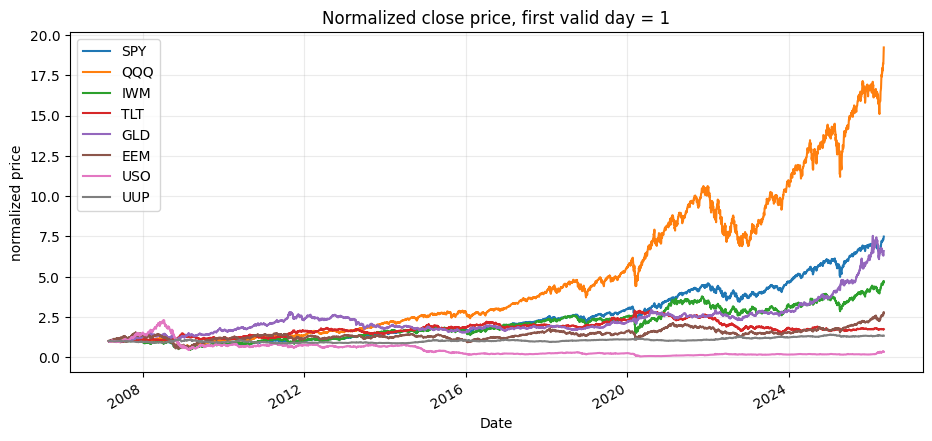

In [7]:
normalized_price = price / price.iloc[0]
ax = normalized_price.plot(linewidth=1.5)
ax.set_title("Normalized close price, first valid day = 1")
ax.set_ylabel("normalized price")
savefig("normalized_prices.png")
plt.show()

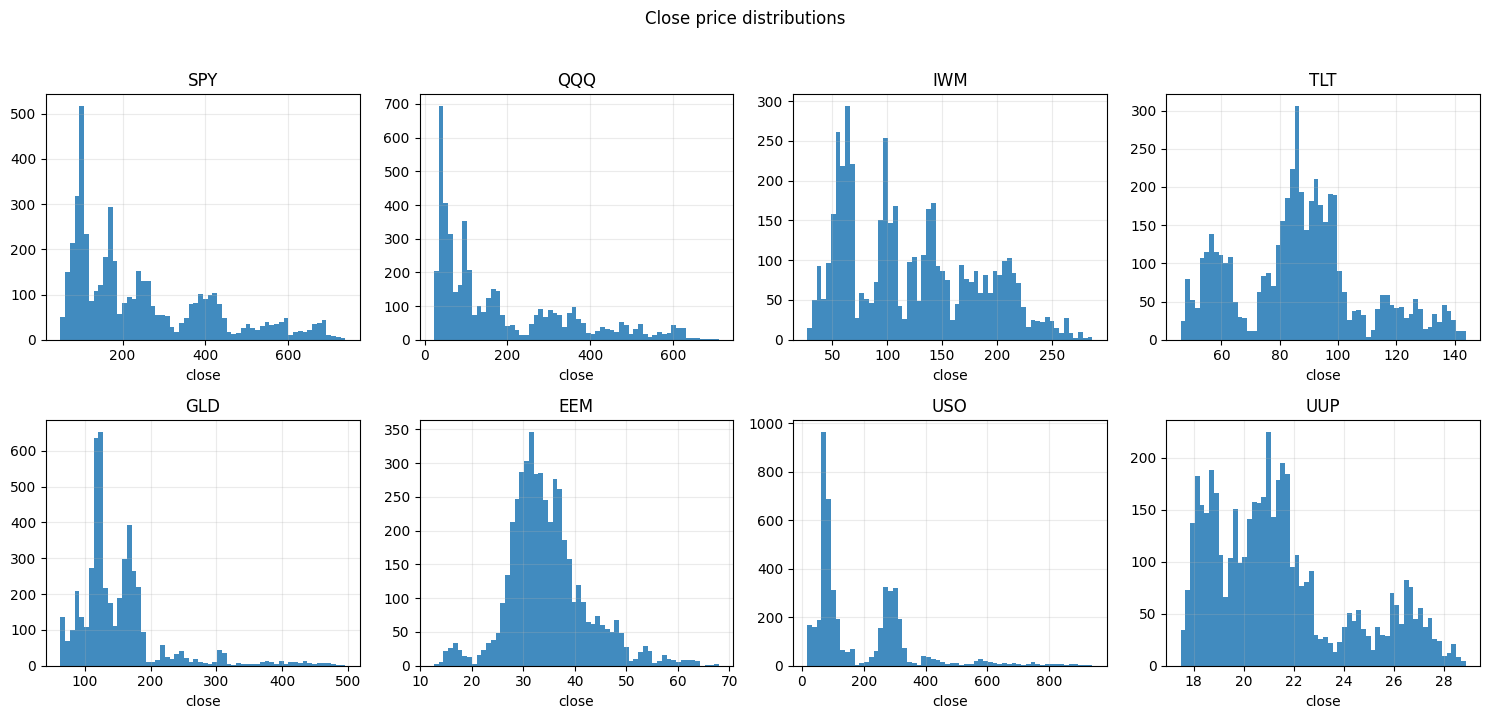

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.ravel()
for ax, col in zip(axes, asset_cols):
    ax.hist(price[col], bins=60, alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("close")
for ax in axes[len(asset_cols):]:
    ax.axis("off")
fig.suptitle("Close price distributions", y=1.02)
plt.tight_layout()
savefig("price_histograms.png")
plt.show()

## Return Distribution

In [9]:
simple_returns = price.pct_change().dropna()
log_returns = np.log(price).diff().dropna()

return_summary = pd.DataFrame({
    "mean_daily": simple_returns.mean(),
    "vol_daily": simple_returns.std(),
    "mean_annualized": simple_returns.mean() * 252,
    "vol_annualized": simple_returns.std() * np.sqrt(252),
    "sharpe_like": (simple_returns.mean() * 252) / (simple_returns.std() * np.sqrt(252)),
    "skew": simple_returns.skew(),
    "kurtosis": simple_returns.kurtosis(),
    "min": simple_returns.min(),
    "p01": simple_returns.quantile(0.01),
    "median": simple_returns.median(),
    "p99": simple_returns.quantile(0.99),
    "max": simple_returns.max(),
}).sort_index()
display(return_summary)

,mean_daily,vol_daily,mean_annualized,vol_annualized,sharpe_like,skew,kurtosis,min,p01,median,p99,max
EEM,0.000366,0.017608,0.092246,0.279514,0.330023,0.577307,18.987067,-0.161662,-0.049738,0.000844,0.050539,0.227699
GLD,0.000455,0.011348,0.114696,0.180138,0.636709,-0.266826,7.197378,-0.102742,-0.031106,0.000556,0.029769,0.112905
IWM,0.000442,0.015608,0.111461,0.247775,0.449849,-0.318894,6.113959,-0.132669,-0.040760,0.000999,0.044483,0.091491
QQQ,0.000711,0.014009,0.179105,0.222388,0.805373,-0.057715,7.563277,-0.119788,-0.039359,0.001190,0.036272,0.121648
SPY,0.000494,0.012421,0.124550,0.197177,0.631665,0.004685,14.506336,-0.109424,-0.035874,0.000705,0.032988,0.145198
TLT,0.000160,0.009544,0.040285,0.151510,0.265890,0.081413,3.219493,-0.066683,-0.023453,0.000447,0.024954,0.075195
USO,0.000048,0.023513,0.012016,0.373261,0.032193,-0.574633,9.526575,-0.253150,-0.065325,0.000715,0.060380,0.166667
UUP,0.000072,0.005105,0.018187,0.081035,0.224430,-0.023759,4.531248,-0.037894,-0.013076,0.000000,0.013295,0.040630


In [10]:
outlier_rows = []
for col in asset_cols:
    r = simple_returns[col]
    outlier_rows.append({
        "asset": col,
        "abs_return_gt_5pct": int((r.abs() > 0.05).sum()),
        "abs_return_gt_10pct": int((r.abs() > 0.10).sum()),
        "worst_date": r.idxmin().date(),
        "worst_return": float(r.min()),
        "best_date": r.idxmax().date(),
        "best_return": float(r.max()),
    })
outlier_report = pd.DataFrame(outlier_rows).set_index("asset")
display(outlier_report)

,abs_return_gt_5pct,abs_return_gt_10pct,worst_date,worst_return,best_date,best_return
asset,,,,,,
SPY,35,4,2020-03-16,-0.109424,2008-10-13,0.145198
QQQ,37,4,2020-03-16,-0.119788,2008-10-13,0.121648
IWM,61,3,2020-03-16,-0.132669,2020-03-24,0.091491
TLT,8,0,2020-03-17,-0.066683,2020-03-20,0.075195
GLD,15,2,2026-01-30,-0.102742,2008-09-17,0.112905
EEM,98,13,2008-10-15,-0.161662,2008-10-13,0.227699
USO,192,18,2020-03-09,-0.253150,2020-04-02,0.166667
UUP,0,0,2007-06-20,-0.037894,2007-06-21,0.040630


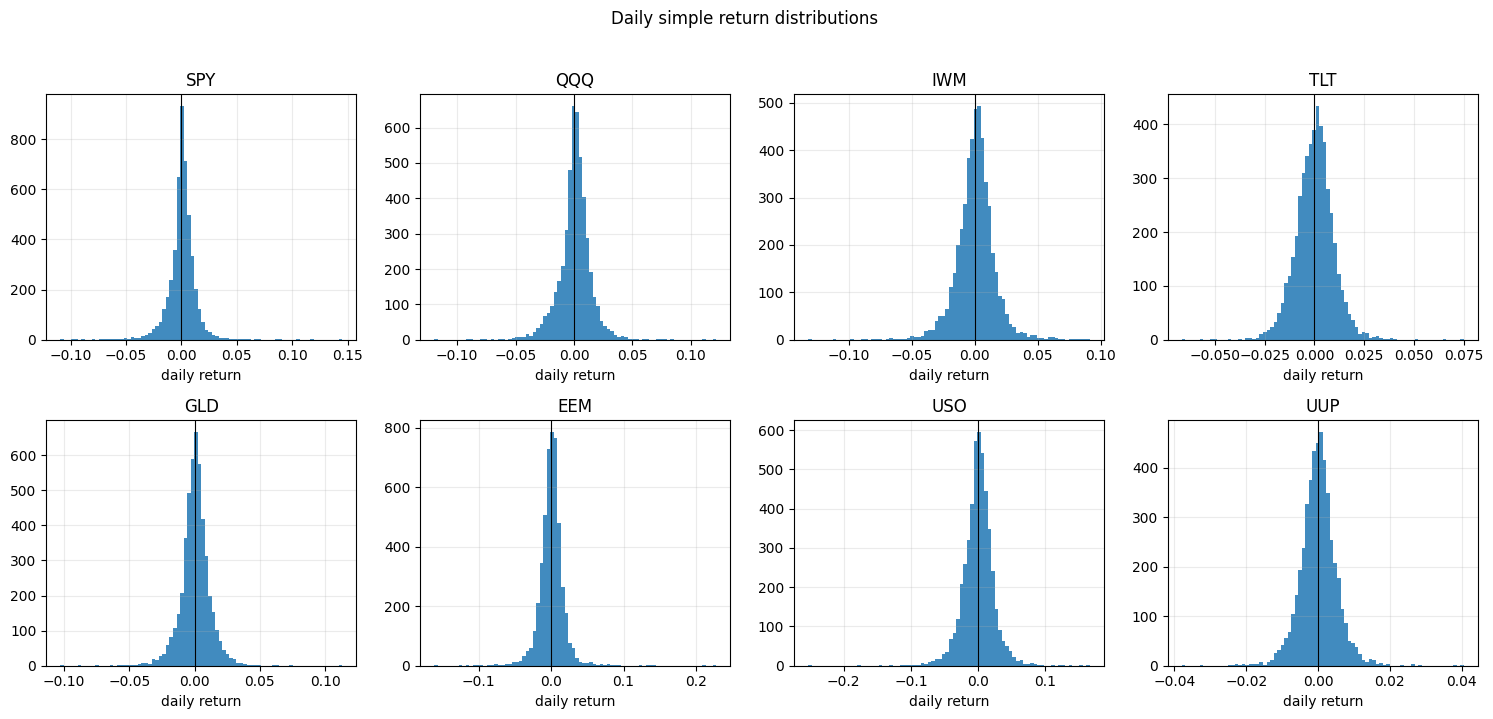

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.ravel()
for ax, col in zip(axes, asset_cols):
    ax.hist(simple_returns[col], bins=80, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel("daily return")
for ax in axes[len(asset_cols):]:
    ax.axis("off")
fig.suptitle("Daily simple return distributions", y=1.02)
plt.tight_layout()
savefig("return_histograms.png")
plt.show()

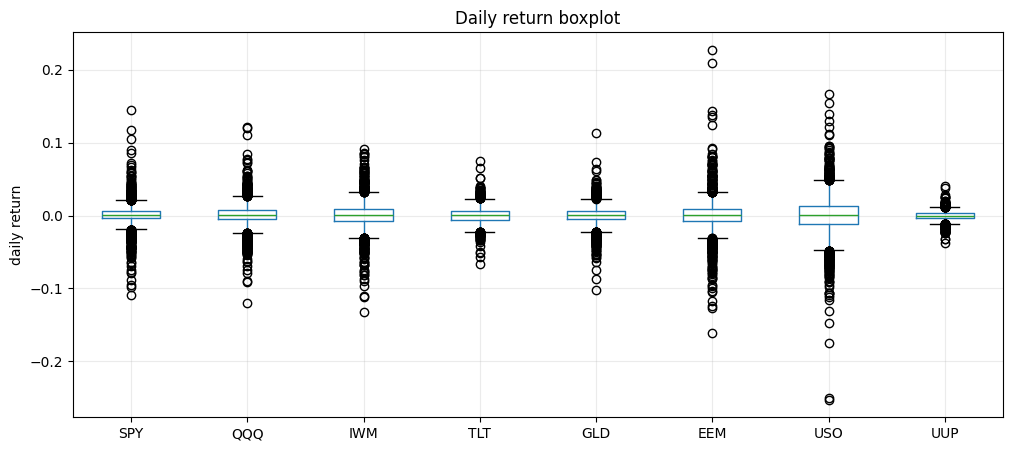

In [12]:
ax = simple_returns.boxplot(figsize=(12, 5), rot=0)
ax.set_title("Daily return boxplot")
ax.set_ylabel("daily return")
savefig("return_boxplot.png")
plt.show()

## Correlation and Risk Regimes

,SPY,QQQ,IWM,TLT,GLD,EEM,USO,UUP
SPY,1.000000,0.924249,0.894651,-0.311987,0.056066,0.825846,0.347205,-0.186064
QQQ,0.924249,1.000000,0.821245,-0.260246,0.047654,0.761633,0.269496,-0.148619
IWM,0.894651,0.821245,1.000000,-0.294418,0.055198,0.759258,0.323318,-0.179711
TLT,-0.311987,-0.260246,-0.294418,1.000000,0.167469,-0.274758,-0.243389,-0.070568
GLD,0.056066,0.047654,0.055198,0.167469,1.000000,0.173565,0.167456,-0.414669
EEM,0.825846,0.761633,0.759258,-0.274758,0.173565,1.000000,0.359484,-0.289244
USO,0.347205,0.269496,0.323318,-0.243389,0.167456,0.359484,1.000000,-0.162811
UUP,-0.186064,-0.148619,-0.179711,-0.070568,-0.414669,-0.289244,-0.162811,1.000000


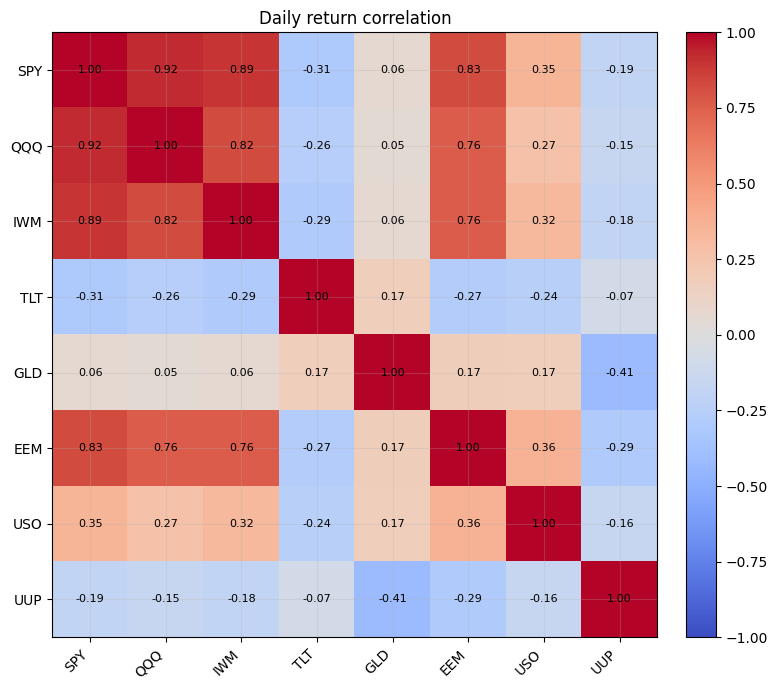

In [13]:
corr = simple_returns.corr()
display(corr)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(asset_cols)), labels=asset_cols, rotation=45, ha="right")
ax.set_yticks(range(len(asset_cols)), labels=asset_cols)
for i in range(len(asset_cols)):
    for j in range(len(asset_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Daily return correlation")
plt.tight_layout()
savefig("return_correlation.png")
plt.show()

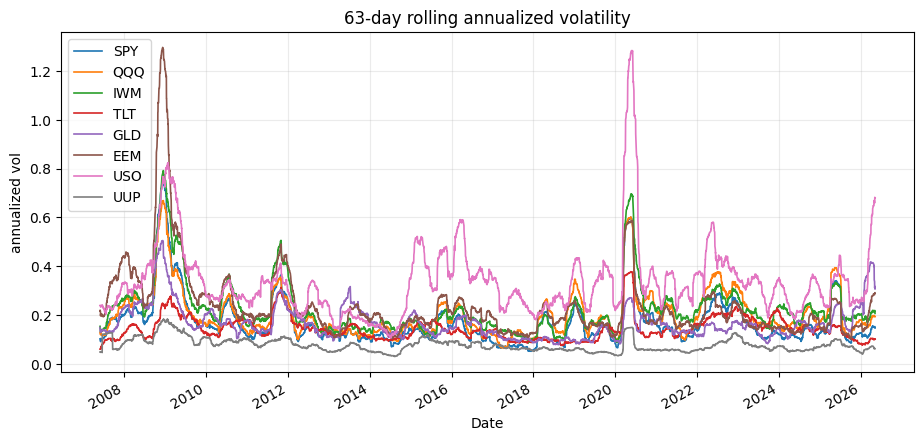

In [14]:
rolling_vol = simple_returns.rolling(63).std() * np.sqrt(252)
ax = rolling_vol.plot(linewidth=1.2)
ax.set_title("63-day rolling annualized volatility")
ax.set_ylabel("annualized vol")
savefig("rolling_volatility.png")
plt.show()

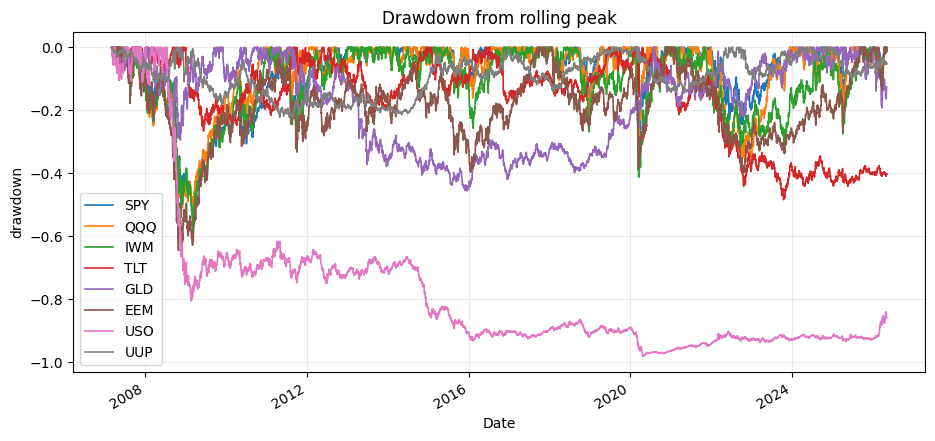

,max_drawdown
USO,-0.981869
EEM,-0.664343
IWM,-0.586400
SPY,-0.551894
QQQ,-0.534040
TLT,-0.483512
GLD,-0.455550
UUP,-0.221909


In [15]:
wealth = (1 + simple_returns).cumprod()
drawdown = wealth / wealth.cummax() - 1
ax = drawdown.plot(linewidth=1.2)
ax.set_title("Drawdown from rolling peak")
ax.set_ylabel("drawdown")
savefig("drawdowns.png")
plt.show()

max_drawdown = drawdown.min().sort_values()
display(max_drawdown.to_frame("max_drawdown"))

## FinCast Window Availability

In [16]:
availability_rows = []
for col in asset_cols:
    n = price[col].dropna().shape[0]
    raw_windows = max(0, n - CONTEXT_LEN - HOLDING_HORIZON + 1)
    stride_windows = int(np.ceil(raw_windows / FINCAST_STRIDE)) if raw_windows else 0
    capped_windows = min(stride_windows, MAX_WINDOWS_PER_ASSET)
    availability_rows.append({
        "asset": col,
        "clean_rows": n,
        "raw_possible_windows": raw_windows,
        "stride_windows": stride_windows,
        "capped_windows_for_v1": capped_windows,
    })
window_availability = pd.DataFrame(availability_rows).set_index("asset")
display(window_availability)
print(f"total capped v1 FinCast windows: {int(window_availability['capped_windows_for_v1'].sum())}")

,clean_rows,raw_possible_windows,stride_windows,capped_windows_for_v1
asset,,,,
SPY,4829,4701,941,256
QQQ,4829,4701,941,256
IWM,4829,4701,941,256
TLT,4829,4701,941,256
GLD,4829,4701,941,256
EEM,4829,4701,941,256
USO,4829,4701,941,256
UUP,4829,4701,941,256


total capped v1 FinCast windows: 2048


## Clean Data Verdict

In [ ]:
issues = []
if duplicate_dates:
    issues.append(f"duplicate_dates={duplicate_dates}")
if not is_monotonic:
    issues.append("dates_not_sorted")
if int(missing_by_col.sum()) > 0:
    issues.append(f"missing_values={int(missing_by_col.sum())}")
if int(inf_by_col.sum()) > 0:
    issues.append(f"infinite_values={int(inf_by_col.sum())}")
if int(nonpositive_by_col.sum()) > 0:
    issues.append(f"nonpositive_prices={int(nonpositive_by_col.sum())}")

verdict = "CLEAN_FOR_V1" if not issues else "NEEDS_ATTENTION"
print("verdict:", verdict)
if issues:
    print("issues:", ", ".join(issues))
else:
    print("No structural data-cleaning issues found. Large return moves remain possible and should be treated as market events unless traced to bad prices.")

clean_df = df.drop_duplicates(subset="Date").sort_values("Date").dropna(axis=0, how="any").reset_index(drop=True)
if WRITE_CLEAN_COPY:
    clean_path = WORKSPACE_ROOT / "data" / "etf_daily_close_clean.csv"
    clean_df.to_csv(clean_path, index=False)
    print(f"wrote clean copy: {clean_path}")